# Load datasets

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/data-crunch-round-1/sample_submission.csv
/kaggle/input/data-crunch-round-1/train.csv
/kaggle/input/data-crunch-round-1/test.csv


In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('/kaggle/input/data-crunch-round-1/train.csv')
data.head()

,ID,Year,Month,Day,kingdom,latitude,longitude,Avg_Temperature,Avg_Feels_Like_Temperature,Temperature_Range,Feels_Like_Temperature_Range,Radiation,Rain_Amount,Rain_Duration,Wind_Speed,Wind_Direction,Evapotranspiration
0,1,1,4,1,Arcadia,24.280002,-37.229980,25.50,30.50,8.5,10.3,22.52,58.89,16,8.6,283,1.648659
1,2,1,4,1,Atlantis,22.979999,-37.329990,299.65,305.15,5.9,8.2,22.73,11.83,12,15.8,161,1.583094
2,3,1,4,1,Avalon,22.880000,-37.130006,26.30,31.50,5.2,6.4,22.73,11.83,12,15.8,161,1.593309
3,4,1,4,1,Camelot,24.180003,-36.929994,24.00,28.40,8.2,10.7,22.67,75.27,16,6.4,346,1.638997
4,5,1,4,1,Dorne,25.780002,-37.530000,28.00,32.80,5.7,10.2,22.35,4.81,8,16.7,185,1.719189


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84960 entries, 0 to 84959
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            84960 non-null  int64  
 1   Year                          84960 non-null  int64  
 2   Month                         84960 non-null  int64  
 3   Day                           84960 non-null  int64  
 4   kingdom                       84960 non-null  object 
 5   latitude                      84960 non-null  float64
 6   longitude                     84960 non-null  float64
 7   Avg_Temperature               84960 non-null  float64
 8   Avg_Feels_Like_Temperature    84960 non-null  float64
 9   Temperature_Range             84960 non-null  float64
 10  Feels_Like_Temperature_Range  84960 non-null  float64
 11  Radiation                     84960 non-null  float64
 12  Rain_Amount                   84960 non-null  float64
 13  R

In [5]:
data.isnull().sum()

ID                              0
Year                            0
Month                           0
Day                             0
kingdom                         0
latitude                        0
longitude                       0
Avg_Temperature                 0
Avg_Feels_Like_Temperature      0
Temperature_Range               0
Feels_Like_Temperature_Range    0
Radiation                       0
Rain_Amount                     0
Rain_Duration                   0
Wind_Speed                      0
Wind_Direction                  0
Evapotranspiration              0
dtype: int64

**There are no any missing values**

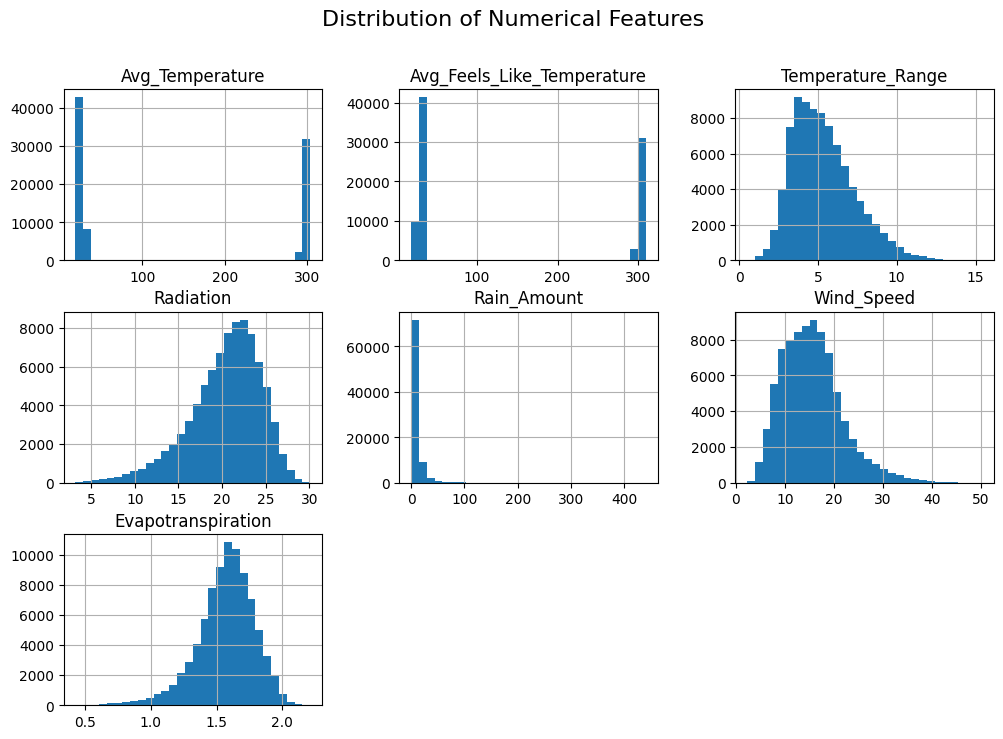

In [6]:
# Select numerical columns
numeric_cols = ["Avg_Temperature", "Avg_Feels_Like_Temperature", "Temperature_Range", 
                "Radiation", "Rain_Amount", "Wind_Speed", "Evapotranspiration"]

# Plot histograms
data[numeric_cols].hist(figsize=(12, 8), bins=30)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()


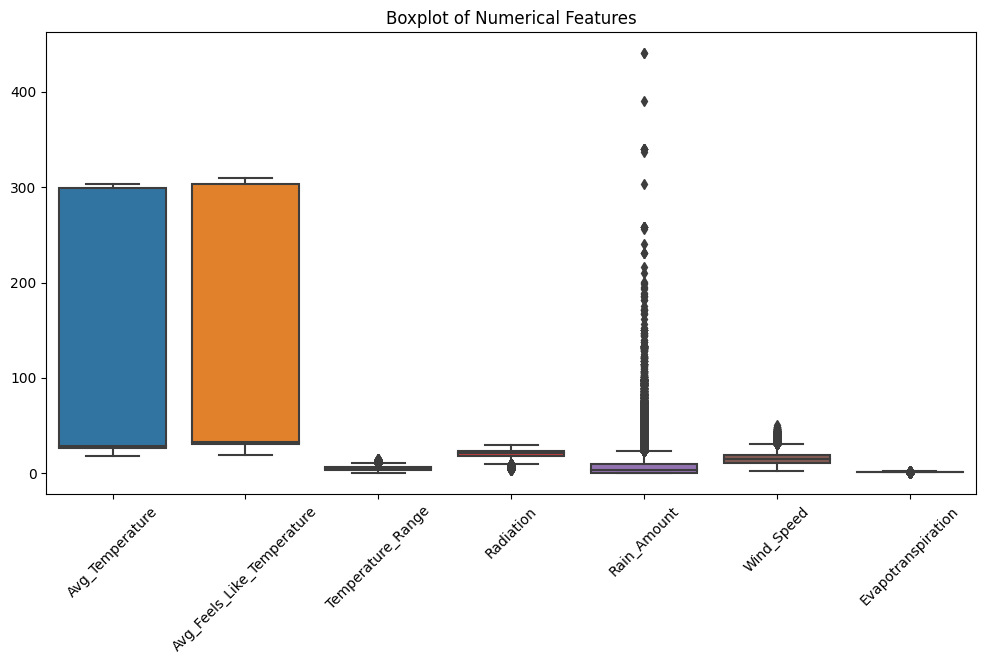

In [7]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features")
plt.show()

In [8]:
Q1 = data["Rain_Amount"].quantile(0.25)  # Lower quartile
Q3 = data["Rain_Amount"].quantile(0.75)  # Upper quartile
IQR = Q3 - Q1

# Clip values beyond 1.5 * IQR limits
data["Rain_Amount"] = np.clip(data["Rain_Amount"], Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

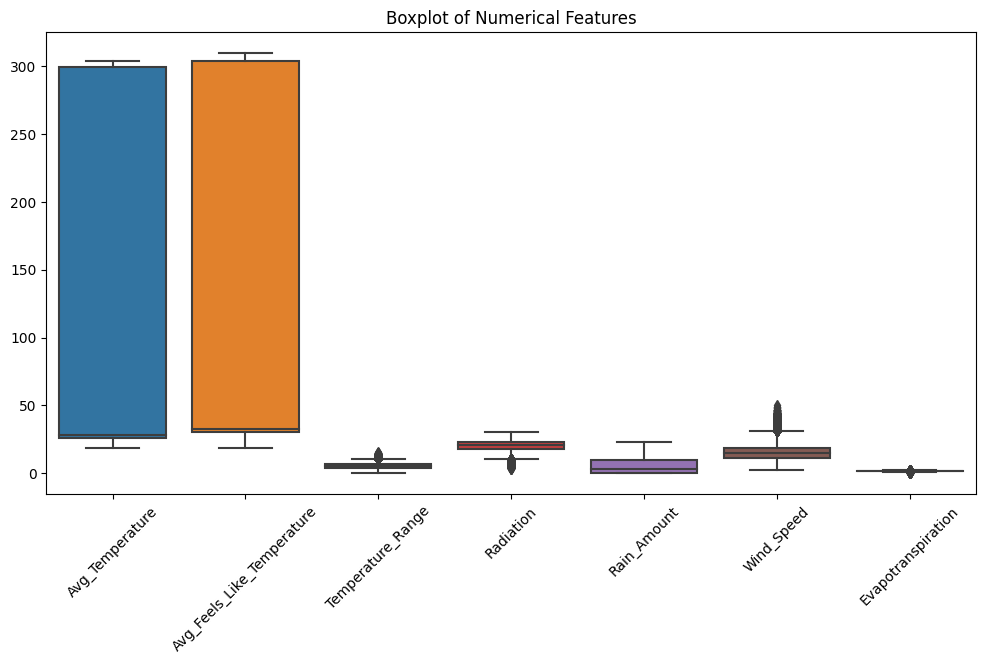

In [9]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features")
plt.show()

In [10]:
temp_cols = ['Avg_Temperature', 'Avg_Feels_Like_Temperature']

for col in temp_cols:
    data[col] = data[col].apply(lambda x: x - 273.15 if (x > 100) else x)

data.head()

,ID,Year,Month,Day,kingdom,latitude,longitude,Avg_Temperature,Avg_Feels_Like_Temperature,Temperature_Range,Feels_Like_Temperature_Range,Radiation,Rain_Amount,Rain_Duration,Wind_Speed,Wind_Direction,Evapotranspiration
0,1,1,4,1,Arcadia,24.280002,-37.229980,25.5,30.5,8.5,10.3,22.52,22.945,16,8.6,283,1.648659
1,2,1,4,1,Atlantis,22.979999,-37.329990,26.5,32.0,5.9,8.2,22.73,11.830,12,15.8,161,1.583094
2,3,1,4,1,Avalon,22.880000,-37.130006,26.3,31.5,5.2,6.4,22.73,11.830,12,15.8,161,1.593309
3,4,1,4,1,Camelot,24.180003,-36.929994,24.0,28.4,8.2,10.7,22.67,22.945,16,6.4,346,1.638997
4,5,1,4,1,Dorne,25.780002,-37.530000,28.0,32.8,5.7,10.2,22.35,4.810,8,16.7,185,1.719189


In [11]:
from sklearn.preprocessing import MinMaxScaler

